# Luftqualitäts-Analyse – Notebook


## Datenquelle


In [1]:
DATA_SOURCE_PATH_ = "./data/openaq.csv"


## Daten einlesen


In [2]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import geodatasets, geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib as mpl

df = pd.read_csv(DATA_SOURCE_PATH_, sep=None, engine="python", encoding="utf-8-sig", dtype=str)
display(df.head())
print("Shape:", df.shape)
print("Spalten:", list(df.columns))


,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label
0,ZA,Alfred Nzo,Luka,"-25.5077634717075, 27.1838594119125",PM10,South Africa,µg/m³,20.0,2023-04-25T01:00:00+02:00,South Africa
1,IN,NaN,"ICRISAT Patancheru, Hyderabad - TSPCB","17.5184, 78.278777",SO2,caaqm,µg/m³,8.9,2022-10-31T02:45:00+01:00,India
2,IT,via Cadello CAGLIARI - Cagliari (CA),CENCA1,"39.23583300015611, 9.115000000173477",SO2,eea,µg/m³,0.5123,2025-01-11T22:00:00+01:00,Italy
3,JP,NaN,南アルプス市鏡中條１６４２－２,"35.601667, 138.498611",NO2,japan-soramame,ppm,0.002,2024-09-23T09:00:00+02:00,Japan
4,KR,NaN,대불,"34.757839999999995, 126.452808",PM10,korea-air,µg/m³,24.0,2025-01-28T10:00:00+01:00,"Korea, Republic of"


Shape: (61177, 10)
Spalten: ['Country Code', 'City', 'Location', 'Coordinates', 'Pollutant', 'Source Name', 'Unit', 'Value', 'Last Updated', 'Country Label']


## Datenüberblick


In [3]:
display(df.head())

print('Shape:', df.shape)

display(df.describe(include='all'))


,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label
0,ZA,Alfred Nzo,Luka,"-25.5077634717075, 27.1838594119125",PM10,South Africa,µg/m³,20.0,2023-04-25T01:00:00+02:00,South Africa
1,IN,NaN,"ICRISAT Patancheru, Hyderabad - TSPCB","17.5184, 78.278777",SO2,caaqm,µg/m³,8.9,2022-10-31T02:45:00+01:00,India
2,IT,via Cadello CAGLIARI - Cagliari (CA),CENCA1,"39.23583300015611, 9.115000000173477",SO2,eea,µg/m³,0.5123,2025-01-11T22:00:00+01:00,Italy
3,JP,NaN,南アルプス市鏡中條１６４２－２,"35.601667, 138.498611",NO2,japan-soramame,ppm,0.002,2024-09-23T09:00:00+02:00,Japan
4,KR,NaN,대불,"34.757839999999995, 126.452808",PM10,korea-air,µg/m³,24.0,2025-01-28T10:00:00+01:00,"Korea, Republic of"


Shape: (61177, 10)


,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label
count,61177,32031,61175,61107,61177,61177,61177,61177,61177,61050
unique,137,4464,13941,15210,13,147,6,13542,5013,122
top,CN,ONTARIO,市环保局,"-25.5956514035919, 27.1256297242044",NO2,eea,µg/m³,0.0,2021-08-09T13:00:00+02:00,China
freq,11098,239,150,69,11129,13050,44669,2660,9582,11098


In [4]:
n = len(df)
summary = (
    pd.DataFrame({
        "NaN_count": df.isna().sum(),
        "NonNaN_count": df.notna().sum()
    })
    .sort_values("NaN_count", ascending=False)
)
print(summary)


               NaN_count  NonNaN_count
City               29146         32031
Country Label        127         61050
Coordinates           70         61107
Location               2         61175
Country Code           0         61177
Pollutant              0         61177
Source Name            0         61177
Unit                   0         61177
Value                  0         61177
Last Updated           0         61177


## Datenbereinigung


In [5]:

# Spaltennamen säubern
df = df.rename(columns=lambda c: c.strip())

# Textspalten normalisieren
df["Pollutant"] = df["Pollutant"].astype(str).str.strip().str.lower()
df["Country Code"] = df["Country Code"].astype(str).str.strip().str.upper()
df["Country Label"] = df["Country Label"].astype(str).str.strip()

# Value -> numeric
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Last Updated -> datetime (mit TZ) => als UTC speichern + in Berlin anzeigen
df["Last Updated"] = pd.to_datetime(df["Last Updated"], utc=True, errors="coerce")
df["Last Updated (Berlin)"] = df["Last Updated"].dt.tz_convert("Europe/Berlin")

# Coordinates -> Latitude/Longitude
latlon = df["Coordinates"].astype(str).str.split(",", n=1, expand=True)
df["Latitude"]  = pd.to_numeric(latlon[0].str.strip(), errors="coerce")
df["Longitude"] = pd.to_numeric(latlon[1].str.strip(), errors="coerce")

# Plausibilitäts-Checks
df.loc[~df["Latitude"].between(-90, 90), "Latitude"] = np.nan
df.loc[~df["Longitude"].between(-180, 180), "Longitude"] = np.nan

# Sentinel-/Fehlwerte behandeln (in OpenAQ kommen häufig -9999 / 9999 vor)
SENTINELS = {-9999, 9999, -999, 999}
df.loc[df["Value"].isin(SENTINELS), "Value"] = np.nan

# Negative Werte sind i.d.R. Mess-/Parsingfehler => auf NaN 
df.loc[df["Value"] < 0, "Value"] = np.nan

display(Markdown("### Missing Values (Anteil)"))
display((df.isna().mean().sort_values(ascending=False) * 100).round(2).to_frame("% NaN"))

# Dedupe: exakte Duplikate entfernen
before = len(df)
df = df.drop_duplicates()
print(f"Duplikate entfernt: {before-len(df)} (neu: {len(df)})")


### Missing Values (Anteil)

,% NaN
City,47.64
Value,2.02
Coordinates,0.11
Longitude,0.11
Latitude,0.11
Location,0.00
Country Code,0.00
Pollutant,0.00
Source Name,0.00
Last Updated,0.00


Duplikate entfernt: 0 (neu: 61177)


In [6]:

# 1) Häufigkeit je Pollutant & Unit
poll_counts = df["Pollutant"].value_counts()
unit_counts = df["Unit"].value_counts()

display(Markdown("### Top Pollutants (Anzahl Messungen)"))
display(poll_counts.head(20).to_frame("count"))

display(Markdown("### Units (Anzahl)"))
display(unit_counts.to_frame("count"))

# 2) Plausibilitätscheck: Value-Quantile je Pollutant
q = (df.dropna(subset=["Value"])
       .groupby("Pollutant")["Value"]
       .quantile([0.01, 0.5, 0.99])
       .unstack())
q.columns = ["p01", "p50", "p99"]
display(Markdown("### Value-Quantile je Pollutant (1%, 50%, 99%)"))
display(q.sort_values("p99", ascending=False).head(20))

# 3) Optional: seltene Pollutants herausfiltern
MIN_N = 200  
keep_pollutants = poll_counts[poll_counts >= MIN_N].index
df_model = df[df["Pollutant"].isin(keep_pollutants)].copy()

display(Markdown(f"**Filter:** Behalte Pollutants mit >= {MIN_N} Messungen. "
                 f"Vorher: {len(df)} Zeilen, danach: {len(df_model)} Zeilen, "
                 f"Pollutants: {df_model['Pollutant'].nunique()}"))

# 4) Finales Analysedatenframe: nur Zeilen mit den wichtigsten Feldern
df_model = df_model.dropna(subset=["Value", "Last Updated", "Latitude", "Longitude", "Country Code", "Pollutant"])

display(Markdown("### Finales Analysedatenframe (df_model)"))
display(df_model.head())
print("Shape df_model:", df_model.shape)


### Top Pollutants (Anzahl Messungen)

,count
Pollutant,
no2,11129
pm2.5,10662
o3,9377
pm10,9264
so2,8061
co,5968
no,4030
nox,2094
pm1,159


### Units (Anzahl)

,count
Unit,
µg/m³,44669
ppm,16188
c,120
%,89
particles/cm³,87
ppb,24


### Value-Quantile je Pollutant (1%, 50%, 99%)

,p01,p50,p99
Pollutant,,,
um003,33.110000,1394.680562,19006.530560
co,0.000000,343.299000,4352.034960
pm10,0.000000,22.000000,312.570000
o3,0.000000,15.480000,224.000000
pm2.5,0.000000,9.200000,154.964700
pm1,0.000000,8.527778,150.501503
no2,0.000000,8.000000,83.149000
relativehumidity,25.120613,56.347887,82.217669
no,0.000000,0.013000,77.835300


**Filter:** Behalte Pollutants mit >= 200 Messungen. Vorher: 61177 Zeilen, danach: 60585 Zeilen, Pollutants: 8

### Finales Analysedatenframe (df_model)

,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label,Last Updated (Berlin),Latitude,Longitude
0,ZA,Alfred Nzo,Luka,"-25.5077634717075, 27.1838594119125",pm10,South Africa,µg/m³,20.0000,2023-04-24 23:00:00+00:00,South Africa,2023-04-25 01:00:00+02:00,-25.507763,27.183859
1,IN,NaN,"ICRISAT Patancheru, Hyderabad - TSPCB","17.5184, 78.278777",so2,caaqm,µg/m³,8.9000,2022-10-31 01:45:00+00:00,India,2022-10-31 02:45:00+01:00,17.518400,78.278777
2,IT,via Cadello CAGLIARI - Cagliari (CA),CENCA1,"39.23583300015611, 9.115000000173477",so2,eea,µg/m³,0.5123,2025-01-11 21:00:00+00:00,Italy,2025-01-11 22:00:00+01:00,39.235833,9.115000
3,JP,NaN,南アルプス市鏡中條１６４２－２,"35.601667, 138.498611",no2,japan-soramame,ppm,0.0020,2024-09-23 07:00:00+00:00,Japan,2024-09-23 09:00:00+02:00,35.601667,138.498611
4,KR,NaN,대불,"34.757839999999995, 126.452808",pm10,korea-air,µg/m³,24.0000,2025-01-28 09:00:00+00:00,"Korea, Republic of",2025-01-28 10:00:00+01:00,34.757840,126.452808


Shape df_model: (59292, 13)


In [7]:
#df.head()
df_model.info()


<class 'pandas.core.frame.DataFrame'>
Index: 59292 entries, 0 to 61176
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype                        
---  ------                 --------------  -----                        
 0   Country Code           59292 non-null  object                       
 1   City                   30806 non-null  object                       
 2   Location               59290 non-null  object                       
 3   Coordinates            59292 non-null  object                       
 4   Pollutant              59292 non-null  object                       
 5   Source Name            59292 non-null  object                       
 6   Unit                   59292 non-null  object                       
 7   Value                  59292 non-null  float64                      
 8   Last Updated           59292 non-null  datetime64[ns, UTC]          
 9   Country Label          59292 non-null  object                       
 10  Las

## Land und Schadstoff-Parameter (Pollutant)

Nur zur Info, damit Filter gewählt werden können


In [8]:
country_map = dict(df_model[["Country Code", "Country Label"]].dropna(subset=["Country Code"]).values)
available_pollutants = sorted(df_model["Pollutant"].dropna().unique().tolist())
print("Länder:", country_map)
print("Pollutants:", available_pollutants)


Länder: {'ZA': 'South Africa', 'IN': 'India', 'IT': 'Italy', 'JP': 'Japan', 'KR': 'Korea, Republic of', 'MX': 'Mexico', 'PK': 'Pakistan', 'PL': 'Poland', 'FR': 'France', 'HU': 'Hungary', 'IE': 'Ireland', 'IL': 'Israel', 'ES': 'Spain', 'DE': 'Germany', 'CN': 'China', 'CL': 'Chile', 'BG': 'Bulgaria', 'CA': 'Canada', 'US': 'United States', 'CO': 'Colombia', 'CY': 'Cyprus', 'MN': 'Mongolia', 'RU': 'Russian Federation', 'SI': 'Slovenia', 'PT': 'Portugal', 'RS': 'Serbia', 'EC': 'Ecuador', 'SE': 'Sweden', 'TH': 'Thailand', 'GB': 'United Kingdom', 'GR': 'Greece', 'AR': 'Argentina', 'AT': 'Austria', 'SK': 'Slovakia', 'TR': 'Turkey', 'CZ': 'Czech Republic', 'TW': 'Taiwan, China', 'BE': 'Belgium', 'BR': 'Brazil', 'NO': 'Norway', 'HR': 'Croatia', 'NL': 'Netherlands', 'PE': 'Peru', 'RO': 'Romania', 'AU': 'Australia', 'FI': 'Finland', 'GT': 'Guatemala', 'LA': "Lao People's Dem. Rep.", 'MK': 'Macedonia, The former Yugoslav Rep. of', 'AJ': 'nan', 'BA': 'Bosnia and Herzegovina', 'AE': 'United Arab Emir

# Filter 


In [9]:

DATE_FROM = "2020-01-01"   # z.B. "2021-01-01"
DATE_TO   = "2025-12-31"   # z.B. "2021-12-31"

# feste Auswahl für ein spezifisches Pollutant
SELECTED_POLLUTANT = "pm2.5"  # z.B. "CO, PM2.5, PM10"


In [10]:
def _filter_by_date(df: pd.DataFrame, date_from: str = "", date_to: str = "") -> pd.DataFrame:
    if "Last Updated" not in df.columns:
        return df
    mask = pd.Series(True, index=df.index)
    if isinstance(date_from, str) and date_from.strip():
        start = pd.to_datetime(date_from).tz_localize("Europe/Berlin").tz_convert("UTC")
        mask &= (df["Last Updated"] >= start)
    if isinstance(date_to, str) and date_to.strip():
        end = pd.to_datetime(date_to).tz_localize("Europe/Berlin").tz_convert("UTC") + pd.Timedelta(days=1)
        mask &= (df["Last Updated"] < end)
    return df[mask]


In [11]:
df_filtered = _filter_by_date(df_model, DATE_FROM, DATE_TO)
print(f"Gefilterte Zeilen: {len(df_filtered)} / {len(df)} (von={DATE_FROM or '-∞'} bis={DATE_TO or '+∞'})")


Gefilterte Zeilen: 55347 / 61177 (von=2020-01-01 bis=2025-12-31)


# Statisische Kennzahlen


In [12]:

def save_dataframe_as_image(df, title, filename):
    """
    Speichert einen Pandas DataFrame als PNG-Bild.

    Die Funktion rendert den DataFrame als Tabelle mit Matplotlib,
    fügt einen Titel hinzu und speichert das Ergebnis als hochauflösendes Bild.
    Geeignet für Reports, Präsentationen und revealing Notebooks.
    """
        
    fig, ax = plt.subplots(figsize=(12, 0.6 * (len(df) + 1)))
    ax.axis('off')

    # Tabelle erzeugen
    table = ax.table(
        cellText=df.round(3).values,
        colLabels=df.columns,
        rowLabels=df.index,
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    # Titel
    # plt.title(title, fontsize=14, pad=20)

    # Speichern
    plt.savefig(filename, bbox_inches='tight', dpi=200)
    plt.close()

In [13]:
def summarize_per_pollutant(frame: pd.DataFrame) -> pd.DataFrame:
    if "Pollutant" not in frame.columns or "Value" not in frame.columns:
        raise ValueError("Benötigte Spalten 'Pollutant' und/oder 'Value' fehlen.")
    return (frame.dropna(subset=["Value"])
                 .groupby("Pollutant")["Value"]
                 .agg(["count", "min", "median", "mean", "max", "std"])
                 .sort_values("mean", ascending=False))

# Deutschland-Filter (Code 'DE' oder Label 'Germany/Deutschland')
if "Country Code" in df_filtered.columns:
    df_de = df_filtered[df_filtered["Country Code"].astype(str).str.upper().str.strip() == "DE"]
elif "Country Label" in df_filtered.columns:
    df_de = df_filtered[df_filtered["Country Label"].astype(str).str.strip().str.lower().isin(["germany", "deutschland"])]
else:
    df_de = df_filtered.iloc[0:0]  

stats_de = summarize_per_pollutant(df_de) if not df_de.empty else pd.DataFrame()
stats_global = summarize_per_pollutant(df_filtered)

display(Markdown(f"### Deutschland — Zeitraum: {DATE_FROM} bis {DATE_TO}"))
display(stats_de)
display(Markdown(f"### Weltweit — Zeitraum: {DATE_FROM} bis {DATE_TO}"))
display(stats_global)

save_dataframe_as_image(
    stats_de,
    title="Deutschland — Zeitraum: 2020-01-01 bis 2025-12-31",
    filename="stats_deutschland.png"
)

save_dataframe_as_image(
    stats_global,
    title="Weltweit — Zeitraum: 2020-01-01 bis 2025-12-31",
    filename="stats_weltweit.png"
)


### Deutschland — Zeitraum: 2020-01-01 bis 2025-12-31

,count,min,median,mean,max,std
Pollutant,,,,,,
co,99,50.000000,318.591000,386.530500,1768.951420,292.918714
o3,322,0.620000,49.720000,44.655731,96.000000,22.602466
so2,130,0.002349,1.000125,24.849279,3052.620000,267.615025
no2,468,0.265925,22.320465,24.595477,86.051086,17.595953
pm10,420,0.000000,9.323800,12.533105,172.990000,12.448016
no,423,0.013000,3.000000,12.157538,320.352844,27.263062
pm2.5,382,0.000000,5.601400,8.454082,44.602551,7.974901


### Weltweit — Zeitraum: 2020-01-01 bis 2025-12-31

,count,min,median,mean,max,std
Pollutant,,,,,,
co,5394,0.0,390.000,6126.580306,3.198676e+06,92657.361797
o3,8465,0.0,19.040,45.375794,2.004076e+03,63.576009
pm10,8495,0.0,21.950,34.866769,3.011492e+03,72.113283
pm2.5,9750,0.0,9.200,16.702207,1.349300e+03,39.807579
no2,10075,0.0,8.000,15.031877,1.010644e+03,25.177728
so2,7159,0.0,2.000,5.534142,3.052620e+03,40.688984
no,3920,0.0,0.013,5.240106,3.777000e+02,17.353438
nox,2089,0.0,0.003,2.431713,2.040000e+02,14.751800


# Visualisierungen


### Vergleich Deutschland vs. Weltweit — `mean` je Schadstoff (nur Pollutants mit >= 200 Messungen)

,Deutschland,Weltweit,n_DE,n_World
Pollutant,,,,
o3,44.655731,45.375794,322,8465
no2,24.595477,15.031877,468,10075
pm10,12.533105,34.866769,420,8495
no,12.157538,5.240106,423,3920
pm2.5,8.454082,16.702207,382,9750


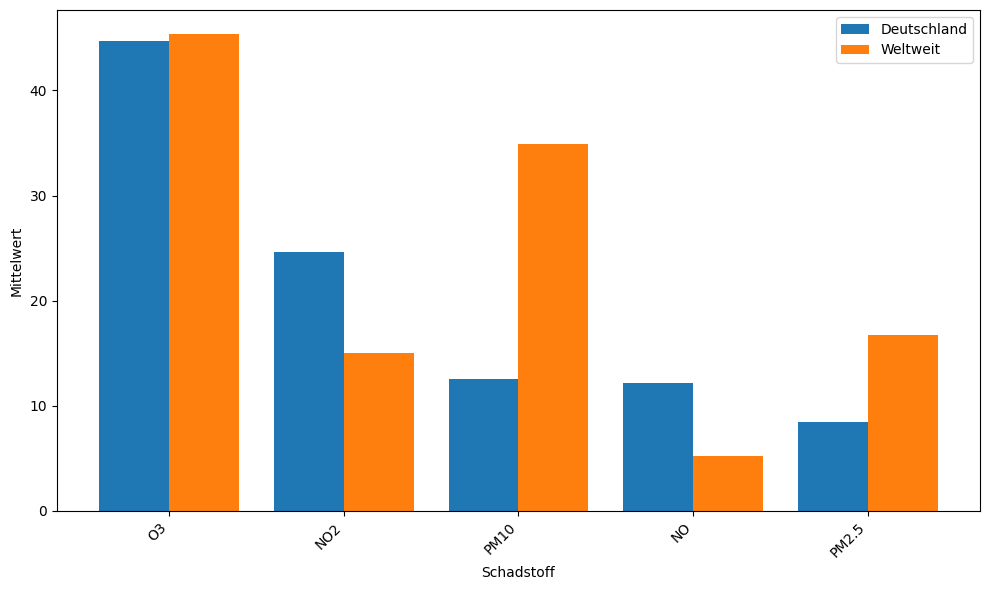

In [14]:
# --- Vergleich Deutschland vs. Weltweit (pro Pollutant) ---#


# Parameter
METRIC = "mean"  # "mean", "median", "min", "max", "std", "count"
METRIC_LABELS = {
    "mean": "Mittelwert",
    "median": "Median",
    "min": "Minimum",
    "max": "Maximum",
    "std": "Standardabweichung",
    "count": "Anzahl",
}
TOP_N = None     # z.B. 10; None = alle

# Mindestanzahl Messungen, damit ein Pollutant im Vergleich landet 
MIN_N_COMPARE = 200

# Prüfen, ob Stats vorhanden sind
if 'stats_de' not in globals() or 'stats_global' not in globals():
    raise NameError("Erwarte Variablen 'stats_de' und 'stats_global' aus den vorherigen Zellen.")

if not isinstance(stats_de, pd.DataFrame) or not isinstance(stats_global, pd.DataFrame):
    raise TypeError("stats_de/stats_global sollten DataFrames sein.")

if stats_de.empty or stats_global.empty:
    display(Markdown("**Hinweis:** Keine Daten für Deutschland oder weltweit vorhanden, um den Vergleich zu zeichnen."))
else:
    if METRIC not in stats_de.columns or METRIC not in stats_global.columns:
        raise ValueError(f"METRIC='{METRIC}' nicht in Spalten vorhanden. Verfügbar: {list(stats_global.columns)}")

    # nur Pollutants mit genügend Daten
    valid = (stats_de.index.intersection(stats_global.index))
    valid = valid[(stats_de.loc[valid, "count"] >= MIN_N_COMPARE) & (stats_global.loc[valid, "count"] >= MIN_N_COMPARE)]

    comp = pd.DataFrame({
        "Deutschland": stats_de.loc[valid, METRIC],
        "Weltweit": stats_global.loc[valid, METRIC],
        "n_DE": stats_de.loc[valid, "count"],
        "n_World": stats_global.loc[valid, "count"],
    }).sort_values("Deutschland", ascending=False)

    if TOP_N is not None:
        comp = comp.head(TOP_N)

    display(Markdown(f"### Vergleich Deutschland vs. Weltweit — `{METRIC}` je Schadstoff "
                     f"(nur Pollutants mit >= {MIN_N_COMPARE} Messungen)"))
    display(comp)

    labels = comp.index.str.upper()
    x = np.arange(len(labels))
    width = 0.4

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, comp["Deutschland"].values, width, label="Deutschland")
    ax.bar(x + width/2, comp["Weltweit"].values, width, label="Weltweit")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel(METRIC_LABELS.get(METRIC, METRIC))
    ax.set_xlabel("Schadstoff")
    #ax.set_title(f"Deutschland vs. Weltweit — {METRIC_LABELS.get(METRIC, METRIC)} je Schadstoff")
    ax.legend()
    plt.tight_layout()
    plt.show()


Boxplot eines einzelnen Pollutant und aus Deutschland


### Deutschland — Boxplot (ausgewählt) (2020-01-01 bis 2025-12-31)

C:\Users\bkr\AppData\Local\Temp\ipykernel_42612\3116355032.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=[str(p) for p in order], showfliers=False)


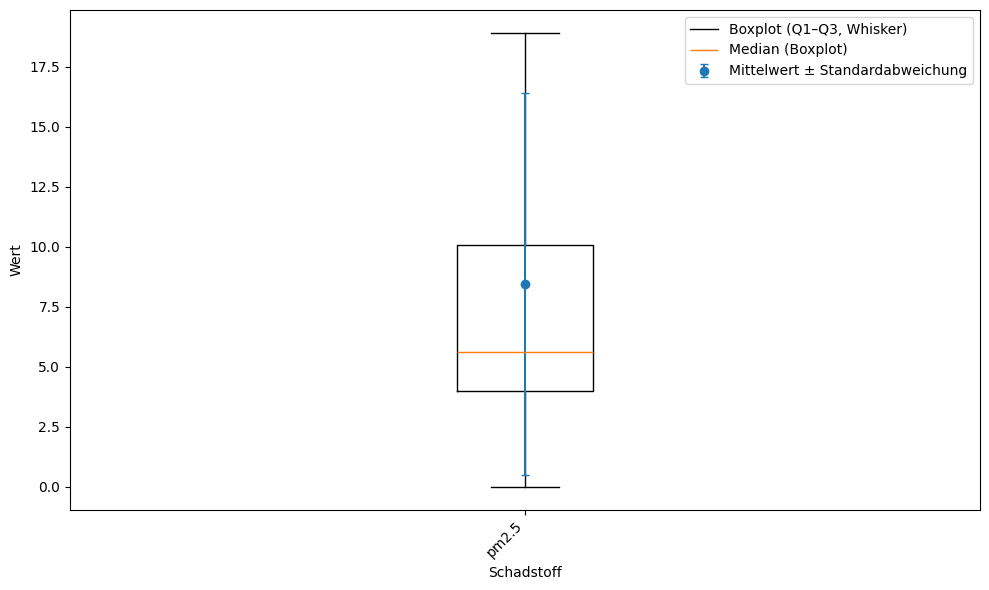

,count,mean,median,std
Pollutant,,,,
pm2.5,382,8.454082,5.6014,7.974901


In [15]:
POLLUTANTS = [SELECTED_POLLUTANT]  # z.B.: ["pm25", "pm10", "no2"] ; leer = alle (sortiert nach Median)

# Sicherstellen, dass df_de existiert
if 'df_de' not in globals():
    raise NameError("Die Variable 'df_de' wurde nicht gefunden. Bitte führe die Zellen zur Deutschland-Selektion zuerst aus.")

if df_de.empty or "Pollutant" not in df_de.columns or "Value" not in df_de.columns:
    display(Markdown("**Hinweis:** Keine Daten für Deutschland vorhanden."))
else:
    # Kennzahlen je Pollutant
    stats_de_full = (df_de.dropna(subset=["Value"])
                        .groupby("Pollutant")["Value"]
                        .agg(["count", "mean", "median", "std"]))

    # Reihenfolge bestimmen
    if POLLUTANTS:
        order = [p for p in POLLUTANTS if p in stats_de_full.index]
    else:
        order = stats_de_full.sort_values("median", ascending=False).index.tolist()

    if len(order) == 0:
        display(Markdown("**Hinweis:** Keine der ausgewählten Pollutants gefunden."))
    else:
        # Daten in dieser Reihenfolge
        data_for_box = [df_de.loc[df_de["Pollutant"] == p, "Value"].dropna().values for p in order]

        # Plot
        display(Markdown(f"### Deutschland — Boxplot (ausgewählt) ({DATE_FROM or '-∞'} bis {DATE_TO or '+∞'})"))
        fig, ax = plt.subplots(figsize=(10, 6))

        bp = ax.boxplot(data_for_box, labels=[str(p) for p in order], showfliers=False)

        # Mittelwert und Std je Pollutant (gleiche Reihenfolge)
        means = stats_de_full.loc[order, "mean"].values
        stds  = stats_de_full.loc[order, "std"].values
        x = np.arange(1, len(order) + 1)

        err = ax.errorbar(x, means, yerr=stds, fmt='o', capsize=3)

        ax.set_xlabel("Schadstoff")
        ax.set_ylabel("Wert")
        #ax.set_title(f"Deutschland — Boxplot + Mittelwert/Std ({DATE_FROM or '-∞'} bis {DATE_TO or '+∞'})")

        # Rotieren & ausrichten
        ax.tick_params(axis='x', labelrotation=45)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('right')

        # Legende: Box (repräsentativ die erste), Medianlinie (repräsentativ die erste), Errorbar-Container
        handles = []
        labels = []
        if len(bp['boxes']) > 0:
            handles.append(bp['boxes'][0])
            labels.append("Boxplot (Q1–Q3, Whisker)")
        if len(bp['medians']) > 0:
            handles.append(bp['medians'][0])
            labels.append("Median (Boxplot)")
        handles.append(err)
        labels.append("Mittelwert ± Standardabweichung")
        ax.legend(handles, labels)

        plt.tight_layout()
        plt.show()

        # Optional: Kennzahlen-Tabelle für die gezeigte Auswahl
        display(stats_de_full.loc[order])


### Deutschland — Zeitreihe für 'PM2.5' (2020-01-01 bis 2025-12-31)

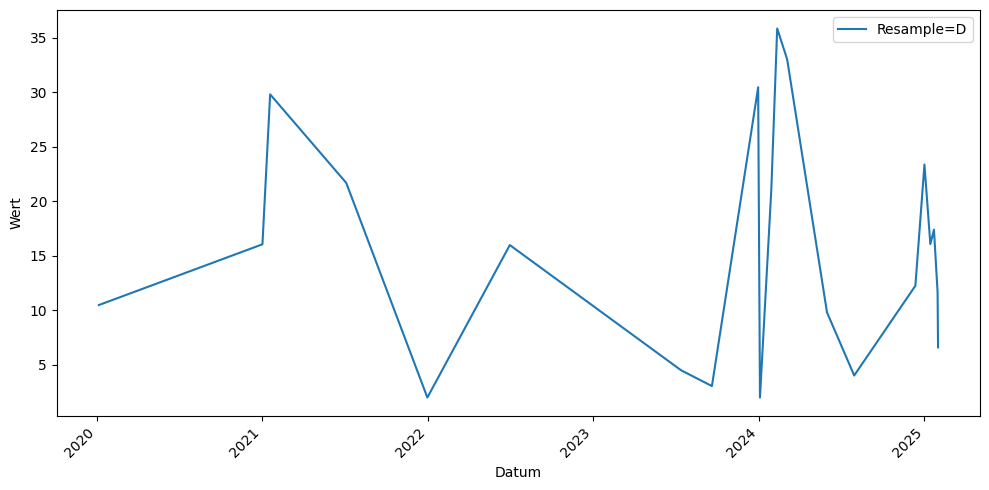

In [16]:

RESAMPLE_FREQ = "D"       # z. B. "D" (täglich), "W" (wöchentlich), None für Rohdaten
ROLLING_DAYS = 0          # z. B. 7 für 7-Tage gleitenden Mittelwert; None/0 zum Deaktivieren

if 'df_de' not in globals():
    raise NameError("Die Variable 'df_de' wurde nicht gefunden. Bitte führe die Zellen zur Deutschland-Selektion zuerst aus.")

if df_de.empty or "Pollutant" not in df_de.columns or "Value" not in df_de.columns:
    display(Markdown("**Hinweis:** Keine Daten für Deutschland vorhanden."))
else:
    # Zeitspalte bestimmen
    if "Last Updated (Berlin)" in df_de.columns:
        dt = pd.to_datetime(df_de["Last Updated (Berlin)"], errors="coerce")
    elif "Last Updated" in df_de.columns:
        dt_raw = pd.to_datetime(df_de["Last Updated"], utc=True, errors="coerce")
        try:
            dt = dt_raw.dt.tz_convert("Europe/Berlin")
        except Exception:
            # falls naive: lokalisiere nach Berlin (ohne Gewähr)
            dt = dt_raw.dt.tz_localize("Europe/Berlin", nonexistent="NaT", ambiguous="NaT")
    else:
        raise ValueError("Es wurde keine Zeitspalte ('Last Updated' oder 'Last Updated (Berlin)') gefunden.")

    # Auswahl nach Pollutant
    sel = df_de[df_de["Pollutant"].astype(str).str.lower() == str(SELECTED_POLLUTANT).lower()].copy()
    sel["dt"] = dt.loc[sel.index]
    sel = sel[sel["dt"].notna() & sel["Value"].notna()].copy()
    sel = sel.sort_values("dt")

    if sel.empty:
        display(Markdown(f"**Hinweis:** Keine Werte für Pollutant '{SELECTED_POLLUTANT}' in Deutschland im gewählten Zeitraum."))
    else:
        # Resample, falls gewünscht
        if RESAMPLE_FREQ:
            ts = sel.set_index("dt")["Value"].resample(RESAMPLE_FREQ).mean()
            ts = ts.dropna()
            x_vals, y_vals = ts.index, ts.values
            label_base = f"Resample={RESAMPLE_FREQ}"
        else:
            x_vals, y_vals = sel["dt"].values, sel["Value"].values
            label_base = "Rohdaten"

        # Optional: gleitender Mittelwert auf resample/Rohdaten
        if ROLLING_DAYS and ROLLING_DAYS > 0:
            # Für Resample='D': Fenster = ROLLING_DAYS; sonst zeitbasiert
            series = pd.Series(y_vals, index=pd.DatetimeIndex(x_vals))
            if RESAMPLE_FREQ == "D":
                roll = series.rolling(window=ROLLING_DAYS, min_periods=max(1, ROLLING_DAYS//2)).mean()
            else:
                # Zeitbasiertes Fenster, sofern index frequenzlos/irregulär
                roll = series.rolling(f"{int(ROLLING_DAYS)}D", min_periods=1).mean()
            x_roll, y_roll = roll.index, roll.values
        else:
            x_roll, y_roll = None, None

        # Plot
        display(Markdown(f"### Deutschland — Zeitreihe für '{SELECTED_POLLUTANT.upper()}' ({DATE_FROM or '-∞'} bis {DATE_TO or '+∞'})"))
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(x_vals, y_vals, label=label_base)
        if x_roll is not None:
            ax.plot(x_roll, y_roll, linestyle='--', label=f"Gleitender Mittelwert ({ROLLING_DAYS} Tage)")
        ax.set_xlabel("Datum")
        ax.set_ylabel("Wert")
        #ax.set_title(f"Deutschland — Zeitreihe {SELECTED_POLLUTANT.upper()} ({DATE_FROM or '-∞'} bis {DATE_TO or '+∞'})")
        ax.legend()

        # X-Ticks lesbarer
        ax.tick_params(axis='x', labelrotation=45)
        for lbl in ax.get_xticklabels():
            lbl.set_horizontalalignment('right')

        plt.tight_layout()
        plt.show()

⚠️ **Hinweis:** Für `pm2.5` sind hier keine Breakpoints hinterlegt. Wenn `Value` bereits US-AQI ist, setze `VALUE_IS_AQI=True`.

**Pollutant:** `PM2.5`  |  **Zeitraum:** 2020-01-01 bis 2025-12-31

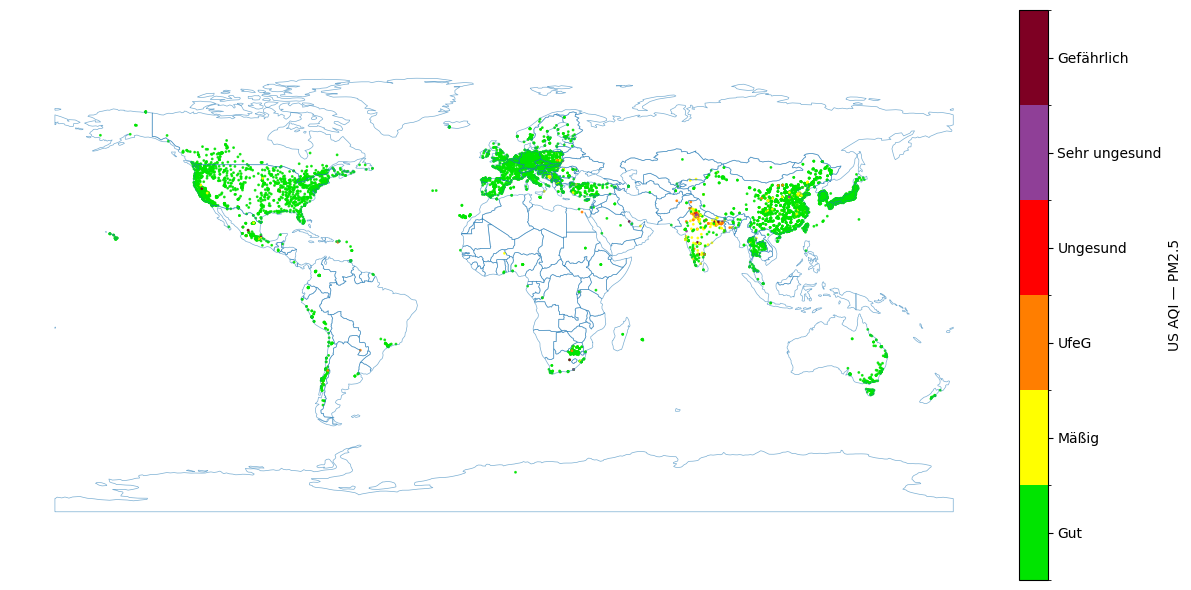

In [17]:
"""
Weltkarte der Messpunkte mit US-AQI-Farben.
- Für PM10/PM2.5 (µg/m³) werden Konzentrationen -> US AQI umgerechnet.
- Für andere Stoffe: VALUE_IS_AQI=True setzen, wenn 'Value' bereits der US-AQI (0–500) ist.
- Purpur erscheint erst ab AQI 201–300, Dunkelrot ab 301+.
"""

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display, Markdown

# SELECTED_POLLUTANT = "co"   # z. B. "co", "pm25", "pm10", "no2", ...
POINT_SIZE = 1                # Markergröße
CLIP_QUANTILES = (0.05, 0.95) # (bleibt ungenutzt bei diskreter AQI-Kartierung)
VALUE_IS_AQI = False          # <- auf True setzen, falls 'Value' bereits US-AQI (0..500) ist

# Falls SELECTED_POLLUTANT/DATUMS-Variablen nicht existieren, defensiv vorbelegen
SELECTED_POLLUTANT = globals().get("SELECTED_POLLUTANT", SELECTED_POLLUTANT)
DATE_FROM = globals().get("DATE_FROM", None)
DATE_TO   = globals().get("DATE_TO", None)

df_use = df_filtered.copy() if 'df_filtered' in globals() else df.copy()

# Prüfen, ob notwendige Spalten vorhanden sind
req_cols = {"Pollutant", "Value", "Latitude", "Longitude"}
missing = [c for c in req_cols if c not in df_use.columns]
if missing:
    raise ValueError(f"Fehlende Spalten: {missing}. Bitte sicherstellen, dass 'Latitude' & 'Longitude' vorhanden sind.")

# Filter auf den Pollutant + gültige Koordinaten
sel = df_use[df_use["Pollutant"].astype(str).str.lower() == str(SELECTED_POLLUTANT).lower()].copy()
sel["Latitude"] = pd.to_numeric(sel["Latitude"], errors="coerce")
sel["Longitude"] = pd.to_numeric(sel["Longitude"], errors="coerce")
sel["Value"] = pd.to_numeric(sel["Value"], errors="coerce")
sel = sel.dropna(subset=["Latitude", "Longitude", "Value"])
sel = sel[sel["Latitude"].between(-90, 90) & sel["Longitude"].between(-180, 180)]

if sel.empty:
    display(Markdown(f"**Hinweis:** Keine Daten für Pollutant '{SELECTED_POLLUTANT}'. Bitte Auswahl/Zeitraum anpassen."))
else:
    # GeoDataFrame der Punkte aus Lat/Lon
    # (wird unten ggf. nach AQI-Berechnung erneut gebaut)
    gdf_pts = gpd.GeoDataFrame(
        sel,
        geometry=gpd.points_from_xy(sel["Longitude"], sel["Latitude"]),
        crs="EPSG:4326"
    )

    # Ländergrenzen laden 
    world = None
    # Versuch A: Natural Earth über NACIS CDN (Admin 0 - Countries, 110m)
    url_ne_countries = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    try:
        world = gpd.read_file(url_ne_countries)
    except Exception:
        # Versuch B: geodatasets, falls installiert (Land-Polygone)
        try:
            import geodatasets
            world_path = geodatasets.get_path("naturalearth.land")
            world = gpd.read_file(world_path)
        except Exception:
            pass
    if world is None:
        raise RuntimeError("Konnte Ländergrenzen nicht laden. Bitte Internetverbindung prüfen oder 'geodatasets' installieren.")

    # Good, Moderate, Unhealthy for SG, Unhealthy, Very Unhealthy, Hazardous
    AQI_COLORS = ["#00E400", "#FFFF00", "#FF7E00", "#FF0000", "#8F3F97", "#7E0023"]  # Grün..Maroon
    AQI_BINS   = [0, 50, 100, 150, 200, 300, 500]                                    # Klassengrenzen
    cmap = ListedColormap(AQI_COLORS, name="us_aqi")
    norm = BoundaryNorm(AQI_BINS, ncolors=cmap.N, clip=True)

    # (Nur PM10/PM2.5; Einheiten: µg/m³)
    BREAKPOINTS = {
        "pm10": [
            (0,   54,   0,  50),
            (55,  154, 51, 100),
            (155, 254,101, 150),
            (255, 354,151, 200),
            (355, 424,201, 300),
            (425, 504,301, 400),
            (505, 604,401, 500),
        ],
        "pm25": [
            (0.0,   12.0,   0,  50),
            (12.1,  35.4,  51, 100),
            (35.5,  55.4, 101, 150),
            (55.5, 150.4, 151, 200),
            (150.5,250.4, 201, 300),
            (250.5,350.4, 301, 400),
            (350.5,500.4, 401, 500),
        ],
    }

    def _aqi_from_conc(x, bps):
        """Lineare Interpolation innerhalb der Breakpoints.
        Werte < min -> 0, Werte > max -> 500 (Kategorie 'Hazardous')."""
        x = float(x)
        if x < bps[0][0]:
            return 0.0
        if x > bps[-1][1]:
            return 500.0
        for c_lo, c_hi, i_lo, i_hi in bps:
            if c_lo <= x <= c_hi:
                return ((i_hi - i_lo) / (c_hi - c_lo)) * (x - c_lo) + i_lo
        return np.nan

    POLL = str(SELECTED_POLLUTANT).lower()
    plot_col = "Value"  # Standard (falls Value bereits AQI ist)

    # Wenn 'Value' KEIN AQI ist und wir Breakpoints kennen: erst AQI berechnen
    if not VALUE_IS_AQI and POLL in BREAKPOINTS:
        sel = sel.copy()
        sel["AQI"] = sel["Value"].apply(lambda v: _aqi_from_conc(v, BREAKPOINTS[POLL]))
        sel["AQI"] = sel["AQI"].round()
        plot_col = "AQI"

        # GeoDataFrame mit AQI-Spalte neu bauen
        gdf_pts = gpd.GeoDataFrame(
            sel,
            geometry=gpd.points_from_xy(sel["Longitude"], sel["Latitude"]),
            crs="EPSG:4326"
        )
    elif not VALUE_IS_AQI and POLL not in BREAKPOINTS:
        # Keine Umrechnung verfügbar -> Hinweis
        display(Markdown(
            f"⚠️ **Hinweis:** Für `{POLL}` sind hier keine Breakpoints hinterlegt. "
            "Wenn `Value` bereits US-AQI ist, setze `VALUE_IS_AQI=True`."
        ))

    display(Markdown(
        f"**Pollutant:** `{SELECTED_POLLUTANT.upper()}`  |  "
        f"**Zeitraum:** {DATE_FROM or '-∞'} bis {DATE_TO or '+∞'}"
    ))

    fig, ax = plt.subplots(figsize=(12, 6))
    world.boundary.plot(ax=ax, linewidth=0.5, alpha=0.6)

    # Diskrete AQI-Farbgebung
    gdf_pts.plot(
        ax=ax, column=plot_col, cmap=cmap, norm=norm,
        markersize=POINT_SIZE, alpha=0.85, legend=False
    )

    # Diskrete Colorbar mit Klassenlabels (Purpur erst ab 201–300)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, boundaries=AQI_BINS)
    cbar.set_ticks([25, 75, 125, 175, 250, 400])  # Klassenmittelpunkte
    cbar.set_ticklabels(["Gut", "Mäßig", "UfeG", "Ungesund", "Sehr ungesund", "Gefährlich"])
    cbar.set_label(f"US AQI — {SELECTED_POLLUTANT.upper()}")

    #ax.set_title(
    #    f"Weltweite Messpunkte — {SELECTED_POLLUTANT.upper()}  |  {DATE_FROM or '-∞'} bis {DATE_TO or '+∞'}"
    #)
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()


**Pollutant:** `PM2.5`  |  **Zeitraum:** 2020-01-01 bis 2025-12-31

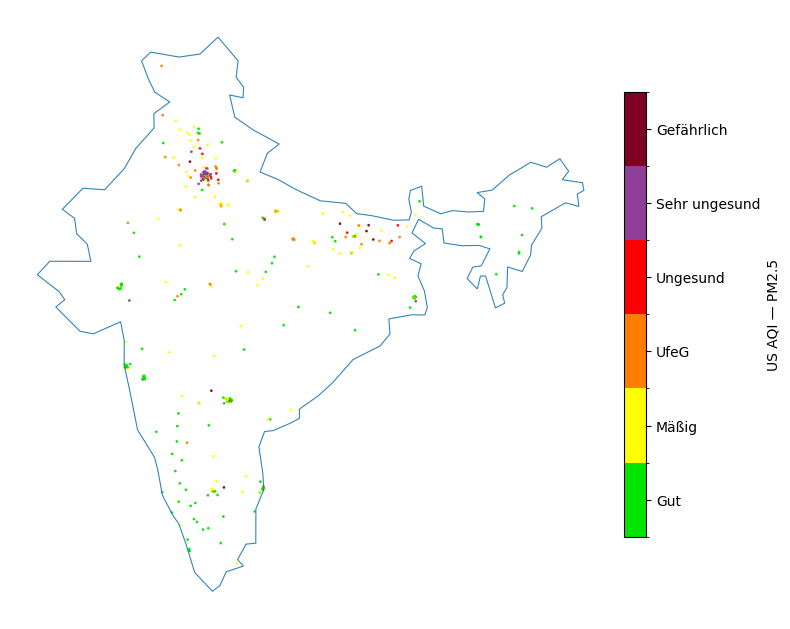

In [18]:
selected_country_name = "India" # Germany, India, China


if "ADMIN" not in world.columns:
    raise RuntimeError(
        "Die geladenen Ländergrenzen enthalten keine 'ADMIN'-Spalte. "
        "Bitte die Natural-Earth Admin-0-Countries Daten nutzen."
    )

selected_country = world[world["ADMIN"] == selected_country_name].to_crs("EPSG:4326")
if selected_country.empty:
    raise RuntimeError("Polygon nicht gefunden.")

if gdf_pts.crs is None:
    gdf_pts.set_crs("EPSG:4326", inplace=True)
gdf_pts = gpd.clip(gdf_pts, selected_country)


display(Markdown(
    f"**Pollutant:** `{SELECTED_POLLUTANT.upper()}`  |  "
    f"**Zeitraum:** {DATE_FROM or '-∞'} bis {DATE_TO or '+∞'}"
))

fig, ax = plt.subplots(figsize=(8, 8))


selected_country.boundary.plot(ax=ax, linewidth=0.8, alpha=0.9)

# Punkte mit diskreter AQI-Farbgebung
gdf_pts.plot(
    ax=ax, column=plot_col, cmap=cmap, norm=norm,
    markersize=POINT_SIZE, alpha=0.85, legend=False
)

# Diskrete Colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm._A = []
cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, boundaries=AQI_BINS)
cbar.set_ticks([25, 75, 125, 175, 250, 400])
cbar.set_ticklabels(["Gut", "Mäßig", "UfeG", "Ungesund", "Sehr ungesund", "Gefährlich"])
cbar.set_label(f"US AQI — {SELECTED_POLLUTANT.upper()}")

minx, miny, maxx, maxy = selected_country.total_bounds
pad_x = (maxx - minx) * 0.05
pad_y = (maxy - miny) * 0.05
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

#ax.set_title(
#    f"{selected_country_name}  — Messpunkte {SELECTED_POLLUTANT.upper()}  |  {DATE_FROM or '-∞'} bis {DATE_TO or '+∞'}"
#)
ax.set_axis_off()
plt.tight_layout()
plt.show()
